 KTAS TRIAGE MODEL - LOGISTIC REGRESSION
Dataset loaded: 10345 patients

 KTAS Levels:
  Level 1 - Resuscitation
  Level 2 - Emergency
  Level 3 - Urgent
  Level 4 - Less Urgent
  Level 5 - Non-Urgent

 Assigning KTAS levels...

 KTAS Distribution:
KTAS_Level
Level 2 - Emergency      1138
Level 3 - Urgent         3327
Level 4 - Less Urgent    2025
Level 5 - Non-Urgent     3855
Name: count, dtype: int64

 PREPROCESSING DATA...
 Preprocessing complete!
Features: 13
KTAS Classes: 4

 Data Split:
  Training: 8276 samples
  Testing: 2069 samples

 Scaling features (required for Logistic Regression)...

 TRAINING LOGISTIC REGRESSION MODEL...
----------------------------------------------------------------------

 TRAINING COMPLETE!
 Accuracy: 0.777 (77.7%)

 CLASSIFICATION REPORT
                       precision    recall  f1-score   support

  Level 2 - Emergency       0.77      0.93      0.85       228
     Level 3 - Urgent       0.86      0.82      0.84       665
Level 4 - Less Urgent    

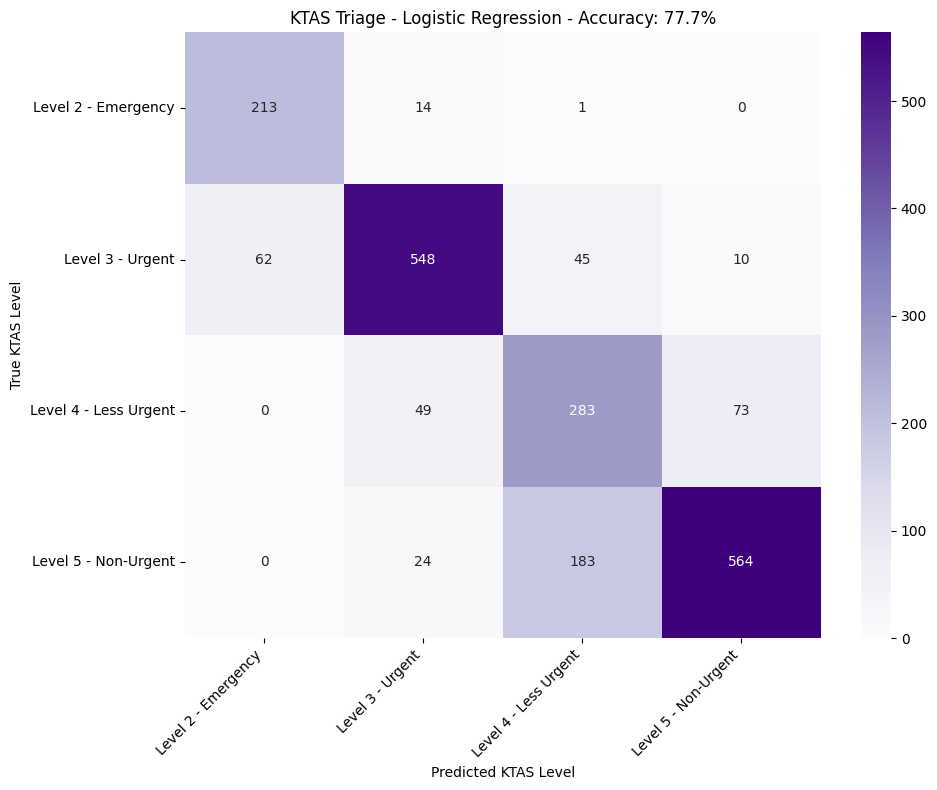


 TOP 10 FEATURES BY COEFFICIENT MAGNITUDE
----------------------------------------------------------------------
Body_Temperature               2.7654 ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
Oxygen_Saturation              1.3343 ██████████████████████████████████████████████████████████████████
Heart_Rate                     0.8973 ████████████████████████████████████████████
Respiratory_Rate               0.7182 ███████████████████████████████████
Diastolic_BP                   0.3661 ██████████████████
Diagnosis                      0.3046 ███████████████
Systolic_BP                    0.2215 ███████████
Alcohol_Use                    0.0541 ██
Family_History                 0.0422 ██
Physical_Activity_Level        0.0314 █

 MODEL INTERCEPTS:
  Level 2 - Emergency            -5.8770
  Level 3 - Urgent               1.8863
  Level 4 - Less Urgent          2.8089
  Level 5 - Non-Urgent 

In [4]:
# ===========================
# KTAS TRIAGE MODEL - LOGISTIC REGRESSION
# ===========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" KTAS TRIAGE MODEL - LOGISTIC REGRESSION")
print("=" * 70)

# Load dataset
df = pd.read_csv('patient_ds2.csv')

print(f"Dataset loaded: {df.shape[0]} patients\n")

print(" KTAS Levels:")
print("  Level 1 - Resuscitation")
print("  Level 2 - Emergency")
print("  Level 3 - Urgent")
print("  Level 4 - Less Urgent")
print("  Level 5 - Non-Urgent\n")

# ===========================
# CREATE KTAS TRIAGE LEVELS
# ===========================

def assign_ktas_level(row):
    """Assign KTAS level based on vital signs"""

    temp = row.get('Body_Temperature', 37)
    hr = row.get('Heart_Rate', 75)
    rr = row.get('Respiratory_Rate', 16)
    o2 = row.get('Oxygen_Saturation', 98)
    systolic = 120

    bp = row.get('Blood_Pressure', '120/80')
    try:
        systolic = int(str(bp).split('/')[0])
    except:
        systolic = 120

    diagnosis = row.get('Diagnosis', 'Healthy')

    # Level 1: Resuscitation
    if o2 < 85 or systolic < 80 or hr > 140 or rr > 35 or temp > 41:
        return 'Level 1 - Resuscitation'

    # Level 2: Emergency
    if (o2 < 90 and diagnosis in ['COVID-19', 'Pneumonia']) or \
       (systolic < 90) or (systolic > 180) or (hr > 120) or (rr > 30) or (temp > 39.5):
        return 'Level 2 - Emergency'

    # Level 3: Urgent
    if (o2 < 94) or (temp > 38.5) or (hr > 100) or (rr > 24) or \
       (diagnosis in ['Asthma', 'Bronchitis', 'Influenza', 'Dengue']):
        return 'Level 3 - Urgent'

    # Level 4: Less Urgent
    if (temp > 37.5 and temp < 38.5) or \
       (diagnosis in ['Migraine', 'Gastritis', 'Sinusitis']):
        return 'Level 4 - Less Urgent'

    # Level 5: Non-Urgent
    return 'Level 5 - Non-Urgent'


print(" Assigning KTAS levels...")
df['KTAS_Level'] = df.apply(assign_ktas_level, axis=1)

print("\n KTAS Distribution:")
print(df['KTAS_Level'].value_counts().sort_index())

# ===========================
# PREPROCESSING
# ===========================

print("\n PREPROCESSING DATA...")

# Drop unnecessary columns
df_model = df.drop(['Patient_ID'], axis=1, errors='ignore')

# Handle missing values
for column in df_model.columns:
    if column == 'KTAS_Level':
        continue
    if df_model[column].dtype == 'object':
        mode_value = df_model[column].mode()[0] if not df_model[column].mode().empty else 'Unknown'
        df_model[column].fillna(mode_value, inplace=True)
    else:
        median_value = df_model[column].median()
        df_model[column].fillna(median_value, inplace=True)

# Extract Blood Pressure
def extract_bp(bp_str):
    if pd.isna(bp_str) or bp_str == '':
        return 120, 80
    try:
        systolic, diastolic = str(bp_str).split('/')
        return float(systolic), float(diastolic)
    except:
        return 120, 80

bp_data = df_model['Blood_Pressure'].apply(extract_bp)
df_model['Systolic_BP'] = [bp[0] for bp in bp_data]
df_model['Diastolic_BP'] = [bp[1] for bp in bp_data]
df_model.drop('Blood_Pressure', axis=1, inplace=True)

# Drop symptoms column
df_model.drop('Symptoms', axis=1, inplace=True, errors='ignore')

# Encode categorical variables
label_encoders = {}
categorical_columns = []

for column in df_model.columns:
    if column == 'KTAS_Level':
        continue
    if df_model[column].dtype == 'object':
        le = LabelEncoder()
        df_model[column] = le.fit_transform(df_model[column].astype(str))
        label_encoders[column] = le
        categorical_columns.append(column)

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_model['KTAS_Level'])
X = df_model.drop('KTAS_Level', axis=1)

print(f" Preprocessing complete!")
print(f"Features: {X.shape[1]}")
print(f"KTAS Classes: {len(target_encoder.classes_)}")

# ===========================
# TRAIN-TEST SPLIT
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Data Split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

# ===========================
# FEATURE SCALING (IMPORTANT FOR LOGISTIC REGRESSION)
# ===========================

print("\n Scaling features (required for Logistic Regression)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===========================
# TRAIN LOGISTIC REGRESSION MODEL
# ===========================

print("\n TRAINING LOGISTIC REGRESSION MODEL...")
print("-" * 70)

lr_model = LogisticRegression(
    multi_class='multinomial',     # For multi-class classification
    solver='lbfgs',                # Optimization algorithm
    max_iter=1000,                 # Maximum iterations
    random_state=42,
    class_weight='balanced',       # Handle imbalanced classes
    C=1.0                          # Regularization parameter
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n TRAINING COMPLETE!")
print(f" Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# ===========================
# DETAILED EVALUATION
# ===========================

print(f"\n CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred,
                          target_names=target_encoder.classes_,
                          zero_division=0))

# Confusion Matrix
print(f"\n CONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
           xticklabels=target_encoder.classes_,
           yticklabels=target_encoder.classes_)
plt.title(f'KTAS Triage - Logistic Regression - Accuracy: {accuracy*100:.1f}%')
plt.ylabel('True KTAS Level')
plt.xlabel('Predicted KTAS Level')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature Coefficients (Importance)
print(f"\n TOP 10 FEATURES BY COEFFICIENT MAGNITUDE")
print("-" * 70)

# Get absolute coefficients (averaged across classes)
avg_coef = np.abs(lr_model.coef_).mean(axis=0)
feature_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': avg_coef
}).sort_values('coefficient', ascending=False).head(10)

for idx, row in feature_coef.iterrows():
    bar = '█' * int(row['coefficient'] * 50)
    print(f"{row['feature']:<30} {row['coefficient']:.4f} {bar}")

# Model Coefficients per Class
print(f"\n MODEL INTERCEPTS:")
for i, intercept in enumerate(lr_model.intercept_):
    print(f"  {target_encoder.classes_[i]:<30} {intercept:.4f}")

# Store model
ktas_model = lr_model
ktas_encoder = target_encoder
ktas_label_encoders = label_encoders
ktas_categorical_columns = categorical_columns
ktas_scaler = scaler  # Important: need scaler for predictions

print(f"\n KTAS TRIAGE MODEL (LOGISTIC REGRESSION) READY!")
print(f"Predicting: {list(target_encoder.classes_)}")
print(f"Model Accuracy: {accuracy*100:.1f}%")
print(f"\n Logistic Regression Benefits:")
print("   Most commonly used in medical research")
print("   Provides probability estimates")
print("   Fast training and prediction")
print("   Works well with limited data")
print("   Interpretable coefficients")
print("=" * 70)


In [7]:
# ===========================
# FIXED: KTAS PREDICTION WITH MATCHING FEATURES
# ===========================

import pandas as pd
import numpy as np

def predict_ktas_patient(age, gender, diagnosis, body_temp, heart_rate,
                        resp_rate, oxygen_sat, systolic_bp, diastolic_bp,
                        family_history='No', smoking='Never', alcohol='No',
                        activity_level='Moderate'):
    """
    Predict KTAS level - FIXED version with correct feature order
    """

    # Create patient data with EXACT same columns as training
    patient_data = pd.DataFrame({
        'Age': [age],
        'Gender': [gender],
        'Heart_Rate': [heart_rate],
        'Body_Temperature': [body_temp],
        'Respiratory_Rate': [resp_rate],
        'Oxygen_Saturation': [oxygen_sat],
        'Family_History': [family_history],
        'Smoking_Status': [smoking],
        'Alcohol_Use': [alcohol],
        'Physical_Activity_Level': [activity_level],
        'Diagnosis': [diagnosis],
        'Systolic_BP': [systolic_bp],
        'Diastolic_BP': [diastolic_bp]
    })

    # Encode categorical variables
    for column in categorical_columns:
        if column in patient_data.columns and column in label_encoders:
            try:
                patient_data[column] = label_encoders[column].transform(patient_data[column])
            except:
                patient_data[column] = 0

    # Reorder columns to match training data
    patient_data = patient_data[X.columns]  # IMPORTANT: Match exact order

    # Scale features
    patient_scaled = ktas_scaler.transform(patient_data)

    # Predict
    prediction = ktas_model.predict(patient_scaled)[0]
    probabilities = ktas_model.predict_proba(patient_scaled)[0]

    # Decode
    predicted_ktas = ktas_encoder.inverse_transform([prediction])[0]
    confidence = probabilities[prediction]

    # Display results
    print(f"\n{'='*75}")
    print(f"🏥 KTAS TRIAGE PREDICTION")
    print(f"{'='*75}")

    print(f"\n👤 PATIENT INFO:")
    print(f"   Age: {age}y | Gender: {gender} | Diagnosis: {diagnosis}")

    print(f"\n📊 VITALS:")
    print(f"   Temp: {body_temp}°C | HR: {heart_rate} bpm | RR: {resp_rate}")
    print(f"   O2: {oxygen_sat}% | BP: {systolic_bp}/{diastolic_bp} mmHg")

    print(f"\n🎯 PREDICTED: {predicted_ktas} ({confidence:.1%})")

    print(f"\n📊 PROBABILITIES:")
    for i, level in enumerate(ktas_encoder.classes_):
        bar = '█' * int(probabilities[i] * 50)
        print(f"   {level:<30} {probabilities[i]:>6.1%} {bar}")

    print(f"{'='*75}\n")

    return predicted_ktas


# ===========================
# TEST PATIENT 1: EMERGENCY
# ===========================

print("\n🚨 PATIENT 1: COVID-19 EMERGENCY")
print("-" * 75)

predict_ktas_patient(
    age=58,
    gender='Male',
    diagnosis='COVID-19',
    body_temp=39.2,
    heart_rate=115,
    resp_rate=28,
    oxygen_sat=88,           # Critical low oxygen
    systolic_bp=110,
    diastolic_bp=72,
    family_history='Yes',
    smoking='Former',
    alcohol='No',
    activity_level='Low'
)


# ===========================
# TEST PATIENT 2: NON-URGENT
# ===========================

print("\n✅ PATIENT 2: HEALTHY/NON-URGENT")
print("-" * 75)

predict_ktas_patient(
    age=28,
    gender='Female',
    diagnosis='Healthy',
    body_temp=37.1,
    heart_rate=72,
    resp_rate=16,
    oxygen_sat=98,
    systolic_bp=118,
    diastolic_bp=76,
    family_history='No',
    smoking='Never',
    alcohol='No',
    activity_level='High'
)

print("\n✅ PREDICTIONS COMPLETE!")



🚨 PATIENT 1: COVID-19 EMERGENCY
---------------------------------------------------------------------------

🏥 KTAS TRIAGE PREDICTION

👤 PATIENT INFO:
   Age: 58y | Gender: Male | Diagnosis: COVID-19

📊 VITALS:
   Temp: 39.2°C | HR: 115 bpm | RR: 28
   O2: 88% | BP: 110/72 mmHg

🎯 PREDICTED: Level 2 - Emergency (96.0%)

📊 PROBABILITIES:
   Level 2 - Emergency             96.0% ████████████████████████████████████████████████
   Level 3 - Urgent                 4.0% █
   Level 4 - Less Urgent            0.0% 
   Level 5 - Non-Urgent             0.0% 


✅ PATIENT 2: HEALTHY/NON-URGENT
---------------------------------------------------------------------------

🏥 KTAS TRIAGE PREDICTION

👤 PATIENT INFO:
   Age: 28y | Gender: Female | Diagnosis: Healthy

📊 VITALS:
   Temp: 37.1°C | HR: 72 bpm | RR: 16
   O2: 98% | BP: 118/76 mmHg

🎯 PREDICTED: Level 4 - Less Urgent (53.9%)

📊 PROBABILITIES:
   Level 2 - Emergency              0.0% 
   Level 3 - Urgent                 0.1% 
   Level 4 - Les